# Stock Market Direction Prediction — A Fully Guided Walkthrough

This notebook builds a machine learning pipeline that predicts whether a
stock's price will go **up or down** over the next trading day, using
technical indicators computed from historical price/volume data.

Every section below explains **why** a choice was made, not just **what**
the code does — the goal is to understand the reasoning, not just copy code.

### What this notebook covers
1. Getting the data, and why we need a data-source fallback
2. Exploratory analysis of price and volume behavior
3. Feature engineering (technical indicators) and the reasoning behind each one
4. Framing the ML problem correctly (classification vs. regression, leakage)
5. Chronological train/test splitting — and why shuffling a time series is a bug
6. Training and comparing three model families
7. Walk-forward validation — testing across multiple market regimes
8. Honest evaluation: baselines, metrics beyond accuracy, and a cost-aware backtest
9. Conclusions, limitations, and what real quant research adds on top of this

> **Disclaimer:** This is an educational project, not investment advice.
> Public daily price data is close to efficiently priced; realistic
> directional accuracy is roughly 50–55%, not 90%+. Any tutorial claiming
> much higher accuracy almost always has a data leak somewhere.


In [1]:
# Core libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Our project modules (in the same folder as this notebook's parent dir)
import sys
sys.path.append('..')

from data_loader import fetch_data
from features import build_feature_table, add_technical_indicators
from model import chronological_split, get_model_zoo, train_model, NaiveBaselines, walk_forward_splits
from evaluate import (
    classification_report_dict, confusion_matrix_df,
    walk_forward_evaluate, backtest_strategy, summarize_backtest
)

plt.rcParams['figure.figsize'] = (11, 4)
pd.set_option('display.max_columns', 20)
print("Libraries loaded.")


Libraries loaded.


## 1. Getting the data

We support two sources:

- **`yfinance`** — pulls real historical data from Yahoo Finance. Requires
  an internet connection.
- **`synthetic`** — generates a realistic fake price series (a GARCH-style
  volatility-clustering random walk) so this notebook runs identically with
  or without internet access, and so results are fully reproducible.

**Set `SOURCE = "yfinance"` and `TICKER` to a real symbol (e.g. `"AAPL"`) if
you have internet access** and want to work with real market data — the
rest of the notebook works unchanged either way.


In [2]:
TICKER = "DEMO"          # e.g. "AAPL", "MSFT", "SPY" if using yfinance
SOURCE = "synthetic"     # "yfinance" for real data, "synthetic" for offline demo
START = "2015-01-01"
END = "2024-01-01"

raw = fetch_data(TICKER, start=START, end=END, source=SOURCE)
print(f"Loaded {len(raw)} rows for {TICKER}, from {raw.index.min().date()} to {raw.index.max().date()}")
raw.tail()


Loaded 2348 rows for DEMO, from 2015-01-01 to 2024-01-01


,Open,High,Low,Close,Volume
Date,,,,,
2023-12-26,315.66,321.13,310.07,315.54,11157587.57
2023-12-27,313.64,320.11,307.41,313.87,7392373.78
2023-12-28,314.40,316.89,311.44,313.92,19647058.26
2023-12-29,314.18,318.80,310.34,314.95,8206109.32
2024-01-01,313.57,318.63,310.66,315.70,4774002.26


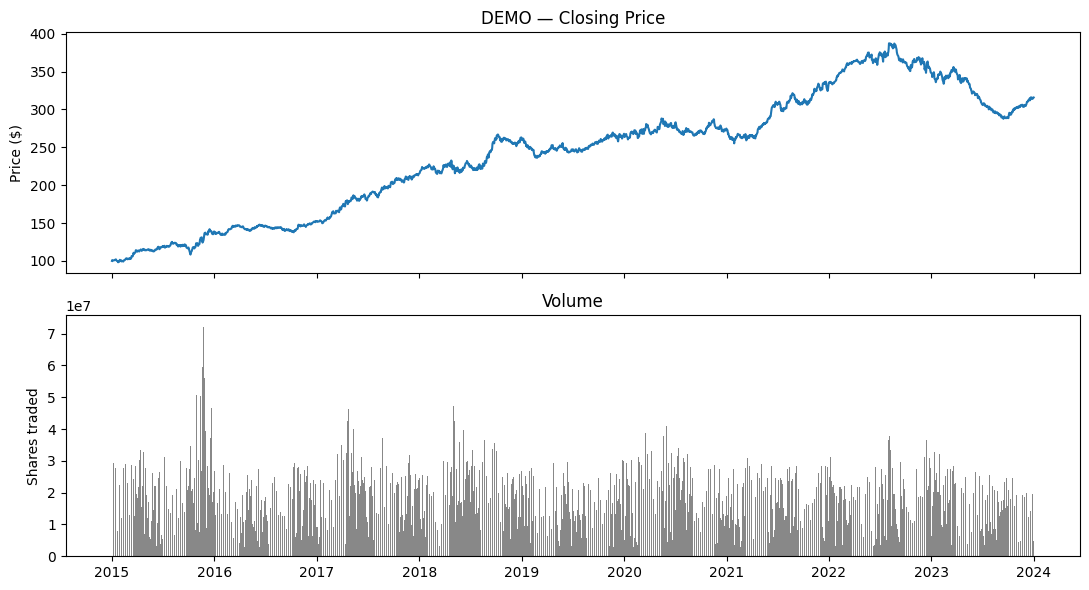

In [3]:
fig, axes = plt.subplots(2, 1, sharex=True, figsize=(11, 6))
axes[0].plot(raw.index, raw['Close'], color='#1f77b4')
axes[0].set_title(f'{TICKER} — Closing Price')
axes[0].set_ylabel('Price ($)')

axes[1].bar(raw.index, raw['Volume'], color='#888', width=1.5)
axes[1].set_title('Volume')
axes[1].set_ylabel('Shares traded')
plt.tight_layout()
plt.show()


### Why not just feed raw price into a model?

Raw closing price is **non-stationary** — its mean and scale drift over
years (a $20 stock and a $200 stock are the "same" kind of pattern to a
human, but not to a model looking at raw numbers). We need to transform
price into features that are roughly scale-invariant and reflect concepts
that actually carry predictive signal: momentum, trend, volatility, and
volume pressure. That's the next section.


## 2. Feature engineering: turning price into signal

We compute a set of **technical indicators**, each with a specific
rationale:

| Feature family | Examples | What it captures |
|---|---|---|
| Trend | SMA/EMA, price-vs-moving-average | Is the stock above or below its recent average trend? |
| Momentum | RSI, MACD, N-day returns | Is the move accelerating, decelerating, over-extended? |
| Volatility | Rolling std of returns, Bollinger Bands | Is the market calm or turbulent right now? |
| Volume pressure | Volume ratio vs. its own average | Is this move backed by unusually high trading activity? |

We also add **lag features** (yesterday's and the day-before's values of
key indicators), because tree-based models don't have any built-in notion
of "what happened recently" — they only see the row in front of them, so we
hand them recent history explicitly as extra columns.

**Critical rule: no lookahead bias.** Every feature at row *t* only uses
information available up to and including day *t*. The one exception is
the **target label itself**, which intentionally looks at day *t+1* (or
further) — but that column is never allowed to double as a feature.


In [4]:
# See the technical indicators before we add lags / target
with_indicators = add_technical_indicators(raw)
indicator_cols = [c for c in with_indicators.columns if c not in raw.columns]
print(f"{len(indicator_cols)} technical indicators added:")
print(indicator_cols)
with_indicators[['Close', 'sma_20', 'rsi_14', 'macd', 'bb_pct_b']].tail()


26 technical indicators added:
['sma_5', 'close_to_sma_5', 'sma_10', 'close_to_sma_10', 'sma_20', 'close_to_sma_20', 'sma_50', 'close_to_sma_50', 'ema_12', 'ema_26', 'rsi_14', 'macd', 'macd_signal', 'macd_hist', 'return_1d', 'return_3d', 'return_5d', 'return_10d', 'volatility_10', 'volatility_20', 'bb_pct_b', 'bb_bandwidth', 'hl_range', 'volume_sma_10', 'volume_ratio', 'volume_change']


,Close,sma_20,rsi_14,macd,bb_pct_b
Date,,,,,
2023-12-26,315.54,310.5540,71.763566,2.991192,0.828661
2023-12-27,313.87,310.9840,63.614855,2.835795,0.697847
2023-12-28,313.92,311.3815,63.747583,2.685717,0.681225
2023-12-29,314.95,311.8790,66.461702,2.619694,0.736601
2024-01-01,315.70,312.4285,68.321498,2.597941,0.784316


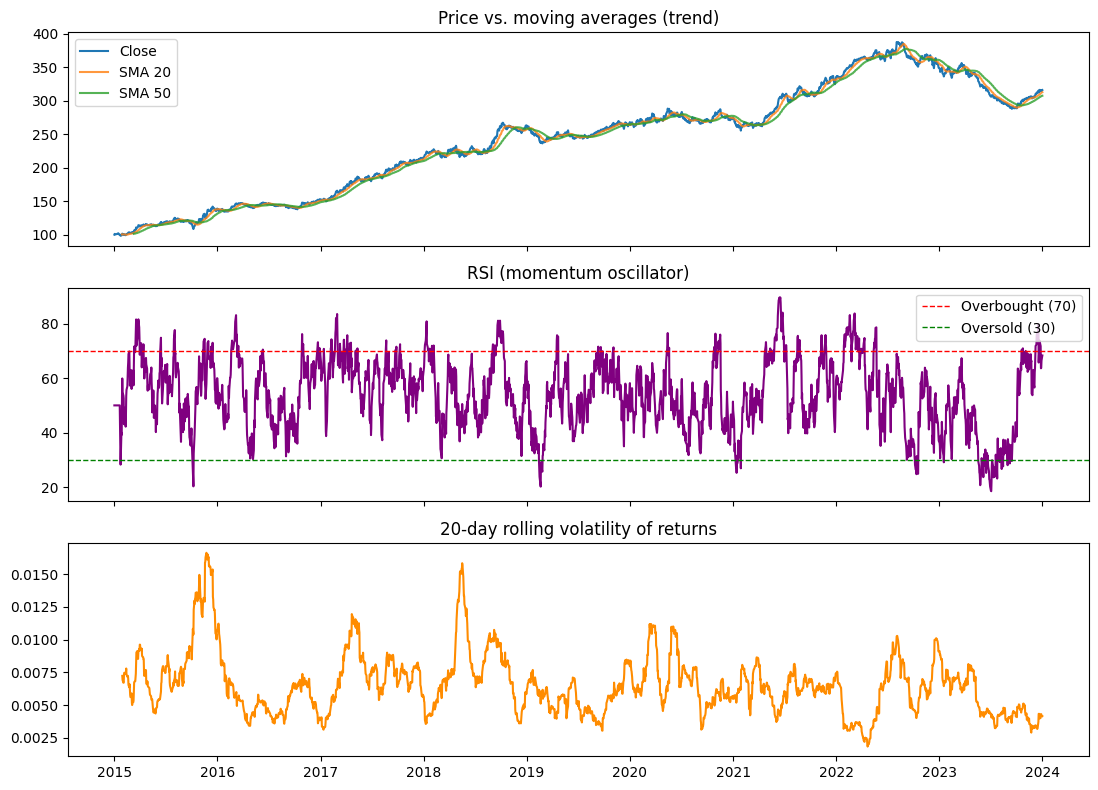

In [5]:
# Visualize a few indicators against price to build intuition
fig, axes = plt.subplots(3, 1, sharex=True, figsize=(11, 8))

axes[0].plot(with_indicators.index, with_indicators['Close'], label='Close')
axes[0].plot(with_indicators.index, with_indicators['sma_20'], label='SMA 20', alpha=0.8)
axes[0].plot(with_indicators.index, with_indicators['sma_50'], label='SMA 50', alpha=0.8)
axes[0].set_title('Price vs. moving averages (trend)')
axes[0].legend()

axes[1].plot(with_indicators.index, with_indicators['rsi_14'], color='purple')
axes[1].axhline(70, color='red', linestyle='--', linewidth=1, label='Overbought (70)')
axes[1].axhline(30, color='green', linestyle='--', linewidth=1, label='Oversold (30)')
axes[1].set_title('RSI (momentum oscillator)')
axes[1].legend()

axes[2].plot(with_indicators.index, with_indicators['volatility_20'], color='darkorange')
axes[2].set_title('20-day rolling volatility of returns')

plt.tight_layout()
plt.show()


## 3. Framing the ML problem

We predict a **binary classification target**: will the closing price be
higher `HORIZON` trading days from now than it is today?

**Why classification instead of predicting the exact future price
(regression)?** Because on noisy daily data, a regression model almost
always learns to just repeat today's price as its prediction for
tomorrow — the errors look small, but the model has learned nothing useful.
Direction is what you'd actually act on (buy vs. don't), and it gives us
clean, honest metrics to evaluate against a coin-flip.


In [6]:
HORIZON = 1  # predict 1 trading day ahead; try 5 or 10 to see how it changes things

table, feature_cols = build_feature_table(raw, horizon=HORIZON)
print(f"Feature table: {table.shape[0]} rows, {len(feature_cols)} feature columns")
print(f"Target balance (1 = up, 0 = down):\n{table['target'].value_counts(normalize=True)}")
table[feature_cols + ['target']].tail()


Feature table: 2298 rows, 35 feature columns
Target balance (1 = up, 0 = down):
target
1    0.520017
0    0.479983
Name: proportion, dtype: float64


,sma_5,close_to_sma_5,sma_10,close_to_sma_10,sma_20,close_to_sma_20,sma_50,close_to_sma_50,ema_12,ema_26,...,return_1d_lag1,return_1d_lag2,return_1d_lag3,rsi_14_lag1,rsi_14_lag2,rsi_14_lag3,volume_ratio_lag1,volume_ratio_lag2,volume_ratio_lag3,target
Date,,,,,,,,,,,,,,,,,,,,,
2023-12-25,314.090,0.004935,313.277,0.007543,309.9830,0.018249,305.5162,0.033137,312.586015,309.610026,...,0.007397,0.001309,0.003750,73.752187,69.249510,68.358789,2.192988,1.066144,1.338929,0
2023-12-26,314.790,0.002383,313.649,0.006029,310.5540,0.016055,305.8836,0.031569,313.040475,310.049283,...,-0.000950,0.007397,0.001309,72.278365,73.752187,69.249510,1.272431,2.192988,1.066144,0
2023-12-27,314.922,-0.003341,313.827,0.000137,310.9840,0.009280,306.2284,0.024954,313.168094,310.332299,...,-0.000317,-0.000950,0.007397,71.763566,72.278365,73.752187,0.899577,1.272431,2.192988,1
2023-12-28,314.982,-0.003372,314.027,-0.000341,311.3815,0.008152,306.5218,0.024136,313.283772,310.598055,...,-0.005293,-0.000317,-0.000950,63.614855,71.763566,72.278365,0.594421,0.899577,1.272431,1
2023-12-29,314.784,0.000527,314.345,0.001925,311.8790,0.009847,306.8202,0.026497,313.540115,310.920421,...,0.000159,-0.005293,-0.000317,63.747583,63.614855,71.763566,1.492352,0.594421,0.899577,1


Notice the target is close to a 50/50 split — this is expected and
important. It means our "floor" for a useful model is a genuine 50%, not
some skewed baseline that's easy to beat by always predicting one class.


## 4. Splitting the data — chronologically, never randomly

This is the single most important methodological decision in this
notebook. **A financial time series must never be split with random
shuffling.** If we did, the model could train on data from, say, March 2022
and be tested on data from January 2022 — meaning it saw the future before
being asked to "predict" the past. This artificially inflates every metric
and the resulting model will fail in live use.

Instead, we always **train on the past and test on a later, unseen
period.**


In [7]:
train_df, test_df = chronological_split(table, test_size=0.2)

print(f"Train: {len(train_df)} rows, {train_df.index.min().date()} to {train_df.index.max().date()}")
print(f"Test:  {len(test_df)} rows, {test_df.index.min().date()} to {test_df.index.max().date()}")

baselines = NaiveBaselines.compute(train_df, test_df)
print("\nNaive baselines the models must beat:")
for k, v in baselines.items():
    print(f"  {k}: {v:.4f}")


Train: 1838 rows, 2015-03-11 to 2022-03-25
Test:  460 rows, 2022-03-28 to 2023-12-29

Naive baselines the models must beat:
  majority_class_accuracy: 0.4630
  persistence_accuracy: 0.5217


Two baselines matter here:
- **Majority-class accuracy** — what you'd get by always predicting the
  more common direction in the training data. On a balanced target this is
  close to 50%.
- **Persistence accuracy** — predicting "tomorrow repeats today's
  direction." Surprisingly, this is sometimes *worse* than a coin flip,
  because daily returns have very little autocorrelation.

Any model we train needs to clear these bars by a meaningful, consistent
margin to be considered to have found real signal.


## 5. Training and comparing models

We train three model families of increasing complexity:

1. **Logistic Regression** — simple, linear, highly interpretable. Our
   sanity-check baseline: if nothing beats this, added complexity isn't
   paying for itself.
2. **Random Forest** — an ensemble of decision trees; captures non-linear
   interactions between indicators (e.g. "RSI is low **and** volume just
   spiked") without much manual tuning.
3. **Gradient Boosting** — usually the strongest tabular-data performer,
   built iteratively to correct previous trees' errors; more prone to
   overfitting if not regularized (we constrain tree depth and subsample
   rows to guard against this).

All three share the same scaling step and are trained purely on the
chronological training set, then evaluated once on the untouched test set.


In [8]:
results = {}
fitted_models = {}

for name, pipe in get_model_zoo().items():
    trained = train_model(pipe, train_df, feature_cols)
    preds = trained.predict(test_df[feature_cols])
    proba = trained.predict_proba(test_df[feature_cols])[:, 1]
    metrics = classification_report_dict(test_df['target'], preds, proba)
    results[name] = metrics
    fitted_models[name] = trained

results_df = pd.DataFrame(results).T
results_df.loc['naive_majority_class'] = {'accuracy': baselines['majority_class_accuracy'], 'precision': np.nan, 'recall': np.nan, 'f1': np.nan, 'roc_auc': np.nan}
results_df.loc['naive_persistence'] = {'accuracy': baselines['persistence_accuracy'], 'precision': np.nan, 'recall': np.nan, 'f1': np.nan, 'roc_auc': np.nan}
results_df.round(4)


,accuracy,precision,recall,f1,roc_auc
logistic_regression,0.4935,0.4737,0.8451,0.6071,0.5343
random_forest,0.4717,0.4658,0.9577,0.6267,0.5260
gradient_boosting,0.4761,0.4643,0.8545,0.6017,0.5281
naive_majority_class,0.4630,NaN,NaN,NaN,NaN
naive_persistence,0.5217,NaN,NaN,NaN,NaN


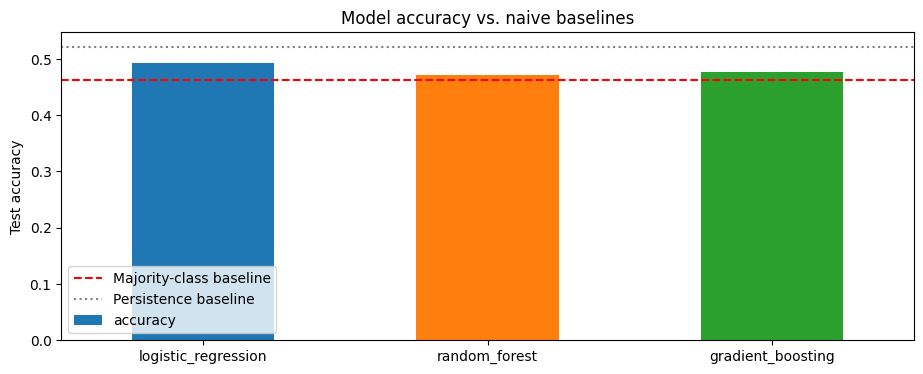

In [9]:
results_df['accuracy'].drop(['naive_majority_class', 'naive_persistence']).plot(
    kind='bar', color=['#1f77b4', '#ff7f0e', '#2ca02c']
)
plt.axhline(baselines['majority_class_accuracy'], color='red', linestyle='--', label='Majority-class baseline')
plt.axhline(baselines['persistence_accuracy'], color='gray', linestyle=':', label='Persistence baseline')
plt.ylabel('Test accuracy')
plt.title('Model accuracy vs. naive baselines')
plt.legend()
plt.xticks(rotation=0)
plt.show()


### How to read this chart honestly

If the colored bars sit only slightly above the dashed baseline lines,
**that is the expected, realistic result** — not a failure of the code.
Public daily OHLCV data has been studied by quantitative funds for decades;
any remaining edge from indicators this simple is small. A model here
"succeeding" means consistently beating the baseline by a couple of
percentage points, not achieving 90%+ accuracy.


In [10]:
best_name = results_df.drop(['naive_majority_class', 'naive_persistence']).astype(float)['roc_auc'].idxmax()
best_model = fitted_models[best_name]
print(f"Best model by ROC-AUC on the single holdout test: {best_name}\n")

preds = best_model.predict(test_df[feature_cols])
cm = confusion_matrix_df(test_df['target'], preds)
cm


Best model by ROC-AUC on the single holdout test: logistic_regression



,Predicted: Down,Predicted: Up
Actual: Down,47,200
Actual: Up,33,180


**Reading the confusion matrix:** rows are what actually happened, columns
are what the model predicted. The diagonal (top-left, bottom-right) is
where the model got it right. Pay attention to whether errors are balanced
across both classes, or if the model is just defaulting toward predicting
one direction most of the time (a common failure mode with imbalanced or
low-signal data).


## 6. Walk-forward validation: does performance hold up over time?

A single train/test split can be lucky — maybe the test window happened to
land in a period the model's assumptions fit well. **Walk-forward
validation** repeats the train/test process multiple times, each time
moving the test window forward in time, so we can see whether performance
is consistent across different market conditions (calm periods, volatile
periods, trending periods, choppy periods).


In [11]:
wf_results = walk_forward_evaluate(
    lambda: get_model_zoo()[best_name], table, feature_cols, n_folds=5
)
wf_results[['accuracy', 'precision', 'recall', 'f1', 'roc_auc', 'test_start', 'test_end']].round(4)


/tmp/ipykernel_649/2063645265.py:4: UserWarning: obj.round has no effect with datetime, timedelta, or period dtypes. Use obj.dt.round(...) instead.
  wf_results[['accuracy', 'precision', 'recall', 'f1', 'roc_auc', 'test_start', 'test_end']].round(4)


,accuracy,precision,recall,f1,roc_auc,test_start,test_end
fold,,,,,,,
1,0.4909,0.5102,0.5245,0.5172,0.4756,2018-09-18,2019-10-07
2,0.4800,0.4706,0.6015,0.5281,0.4857,2019-10-08,2020-10-26
3,0.4873,0.5612,0.3595,0.4382,0.5194,2020-10-27,2021-11-15
4,0.5127,0.5263,0.6294,0.5732,0.5068,2021-11-16,2022-12-05
5,0.5341,0.4970,0.6434,0.5608,0.5816,2022-12-06,2023-12-29


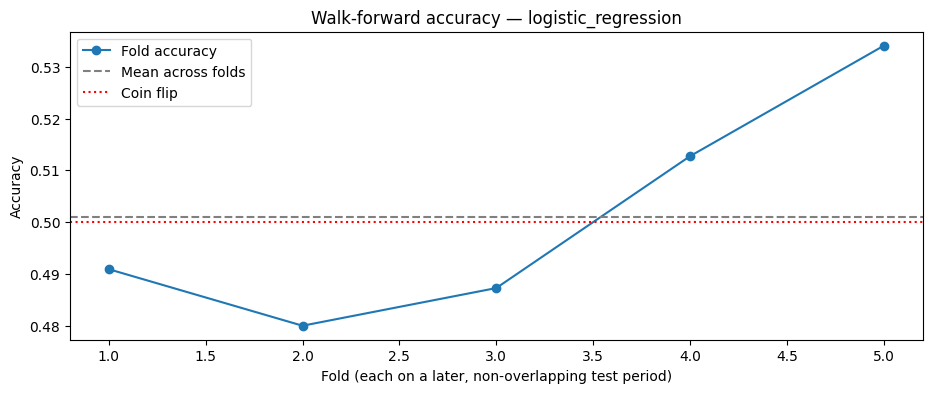

Mean accuracy across folds: 0.5010 (+/- 0.0221)


In [12]:
plt.plot(wf_results.index, wf_results['accuracy'], marker='o', label='Fold accuracy')
plt.axhline(wf_results['accuracy'].mean(), color='gray', linestyle='--', label='Mean across folds')
plt.axhline(0.5, color='red', linestyle=':', label='Coin flip')
plt.xlabel('Fold (each on a later, non-overlapping test period)')
plt.ylabel('Accuracy')
plt.title(f'Walk-forward accuracy — {best_name}')
plt.legend()
plt.show()

print(f"Mean accuracy across folds: {wf_results['accuracy'].mean():.4f} (+/- {wf_results['accuracy'].std():.4f})")


If accuracy swings wildly between folds (e.g. 60% in one, 40% in the next),
that's a sign the model isn't finding a stable, generalizable pattern —
it's fitting noise specific to each period. A consistent result close to,
and only modestly above, the baseline is actually the more trustworthy
outcome.


## 7. Backtest: translating predictions into $ terms

Accuracy alone doesn't tell us whether a model would make money. A model
could be right slightly more often than wrong but still lose overall if
its rare wrong predictions coincide with big market moves. So we simulate
a simple strategy:

- **On days the model predicts "up," hold the stock.**
- **On days it predicts "down," stay in cash.**
- **Every time the position changes, pay a small trading cost** (in basis
  points), because ignoring transaction costs is one of the most common
  ways naive backtests lie.

We compare this against **buy-and-hold** — simply holding the stock for
the entire test period, doing nothing.


Backtest summary (test period, net of costs):
  strategy_total_return: -0.11119220345350689
  buy_hold_total_return: -0.1295836779707742
  annualized_strategy_return_est: -0.06253382273888619
  sharpe_ratio_est: -0.7031690988225362
  n_test_days: 460


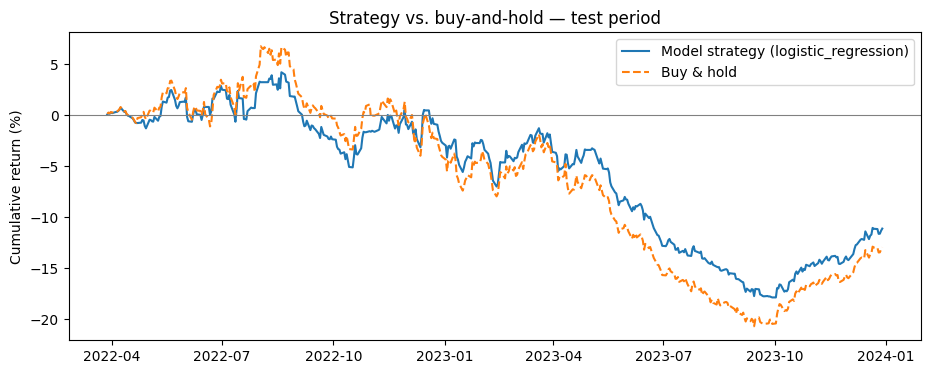

In [13]:
bt = backtest_strategy(test_df, preds, cost_bps=5.0)
summary = summarize_backtest(bt)

print("Backtest summary (test period, net of costs):")
for k, v in summary.items():
    print(f"  {k}: {v}")

plt.plot(bt.index, bt['strategy_cum_return'] * 100, label=f'Model strategy ({best_name})')
plt.plot(bt.index, bt['buy_hold_cum_return'] * 100, label='Buy & hold', linestyle='--')
plt.axhline(0, color='gray', linewidth=0.8)
plt.ylabel('Cumulative return (%)')
plt.title('Strategy vs. buy-and-hold — test period')
plt.legend()
plt.show()


### What this backtest does *not* account for

To stay honest about the limitations of this educational demo, note this
simplified backtest ignores:
- **Slippage** (the price often moves against you between deciding to
  trade and the trade executing)
- **Position sizing / risk management** (real strategies rarely go 100%
  in or 100% out)
- **Taxes, borrowing costs for shorting, and liquidity constraints**
- **Survivorship bias** (we only tested one ticker's history as it exists
  today)

A model that "beats" buy-and-hold here is a promising research result, not
a ready-to-trade system.


## 8. Conclusions & what real quant research adds on top of this

**What we built:** a disciplined, leakage-free pipeline that engineers
technical-indicator features, respects time order in every validation
step, compares against honest baselines, and evaluates with both
classification metrics and a cost-aware backtest.

**What we'd expect to see:** models landing close to, and only somewhat
above, the ~50% baseline — because daily OHLCV technical data on a single
liquid stock is close to a textbook case of a heavily-arbitraged, close to
efficient market.

**What professional/institutional approaches typically add** (all beyond
this notebook's scope, but worth knowing about):
- Alternative/unstructured data (news sentiment, earnings call transcripts,
  satellite/foot-traffic data, options market positioning)
- Cross-sectional models (ranking many stocks against each other, rather
  than predicting one stock in isolation)
- Much more rigorous backtesting (transaction cost modeling, market impact,
  point-in-time data with no survivorship bias, walk-forward re-training)
- Portfolio construction and risk management layered on top of any signal
- Ensemble/regime-aware modeling that adapts to changing market conditions

**Bottom line:** this project is a solid, honest foundation for learning
applied ML on time-series data and the evaluation discipline that financial
data specifically demands. It is **not** a trading system, and its
predictions should not be used to make real investment decisions.
